# Breast Cancer Prediction Analysis

This notebook explores a breast cancer prediction dataset from Kaggle.
The data comes from the University of Wisconsin Hospitals and contains measurements taken from cell nuclei in breast tissue samples.

Each row in the dataset represents one patient. The columns are:

| Column | What it means |
|---|---|
| mean_radius | Average size (radius) of the cell nucleus |
| mean_texture | How rough or smooth the cell surface looks |
| mean_perimeter | The boundary length around the cell nucleus |
| mean_area | The total area of the cell nucleus |
| mean_smoothness | How smooth the edges of the nucleus are |
| diagnosis | 0 = Benign (not cancer), 1 = Malignant (cancer) |

## Analytical Questions

I will try to answer these three questions through my analysis:

1. **Do cell measurements differ between benign and malignant tumors?**
   For example, do malignant cells tend to be larger or have different shapes?

2. **Which measurement is most strongly connected to a malignant diagnosis?**
   I want to find the feature that separates the two groups the most.

3. **Is there a combination of measurements that clearly separates benign from malignant cases?**
   Looking at two features together might reveal patterns that one feature alone cannot show.

Dataset source: https://www.kaggle.com/datasets/merishnasuwal/breast-cancer-prediction-dataset

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# raw copy as the starting point of the pipeline
df_raw = pd.read_csv("data/Breast_cancer_data.csv")

df_raw.head()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0
1,20.57,17.77,132.90,1326.0,0.08474,0
2,19.69,21.25,130.00,1203.0,0.10960,0
3,11.42,20.38,77.58,386.1,0.14250,0
4,20.29,14.34,135.10,1297.0,0.10030,0


## Data Cleaning Pipeline

In this section, I chose to follow the pandas standard workflow for cleaning data:
1. Start from raw data
2. Inspect possible data quality problems
3. Convert types
4. Fix issues
5. Use cleaned data for analysis

In [27]:
def inspect_data_quality(df):
    """Return simple quality metrics before cleaning."""
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    quality = {
        "rows": len(df),
        "columns": df.shape[1],
        "missing_values_total": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
        "diagnosis_unique_values": sorted(df["diagnosis"].dropna().unique().tolist()),
        "negative_values_in_numeric": int((df[numeric_cols] < 0).sum().sum()),
    }
    return quality


def convert_data_types(df):
    """Convert columns to expected data types."""
    df_out = df.copy()

    feature_cols = [col for col in df_out.columns if col != "diagnosis"]
    for col in feature_cols:
        df_out[col] = pd.to_numeric(df_out[col], errors="coerce")

    df_out["diagnosis"] = pd.to_numeric(df_out["diagnosis"], errors="coerce").astype("Int64")
    return df_out


def fix_data_issues(df):
    """Fix common issues in a simple and transparent way."""
    df_out = df.copy()

    # Drop duplicate rows.
    df_out = df_out.drop_duplicates()

    # Keep only valid diagnosis values (0 and 1).
    df_out = df_out[df_out["diagnosis"].isin([0, 1])]

    # Fill missing numeric values with median.
    numeric_cols = df_out.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        df_out[col] = df_out[col].fillna(df_out[col].median())

    # Numeric measurements should not be negative in this dataset.
    feature_cols = [col for col in numeric_cols if col != "diagnosis"]
    for col in feature_cols:
        df_out[col] = df_out[col].clip(lower=0)

    return df_out


# Pipeline execution
quality_before = inspect_data_quality(df_raw)
df_typed = convert_data_types(df_raw)
df = fix_data_issues(df_typed)  # from now on, use df as cleaned data
quality_after = inspect_data_quality(df)

print("Quality before cleaning:")
print(quality_before)
print("\nQuality after cleaning:")
print(quality_after)
print("\nCleaned shape:", df.shape)

Quality before cleaning:
{'rows': 569, 'columns': 6, 'missing_values_total': 0, 'duplicate_rows': 0, 'diagnosis_unique_values': [0, 1], 'negative_values_in_numeric': 0}

Quality after cleaning:
{'rows': 569, 'columns': 6, 'missing_values_total': 0, 'duplicate_rows': 0, 'diagnosis_unique_values': [0, 1], 'negative_values_in_numeric': 0}

Cleaned shape: (569, 6)


### Summary from data cleaning and initial inspection on the cleaned data

After running the cleaning pipeline I can see that there were no duplicates or missing values. The cleaned shape is the same as the raw data, which shows that the raw data was already clean from the beginning.

Before creating visualizations, I want to understand the structure of the cleaned data.

The following cells inspect:

* number of rows and columns
* column names
* data types
* missing values
* summary statistics

In [18]:
df.shape

(569, 6)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   mean_radius      569 non-null    float64
 1   mean_texture     569 non-null    float64
 2   mean_perimeter   569 non-null    float64
 3   mean_area        569 non-null    float64
 4   mean_smoothness  569 non-null    float64
 5   diagnosis        569 non-null    Int64  
dtypes: Int64(1), float64(5)
memory usage: 27.4 KB


In [29]:
df.describe()

,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,diagnosis
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.0
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.0
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.0
50%,13.370000,18.840000,86.240000,551.100000,0.095870,1.0
75%,15.780000,21.800000,104.100000,782.700000,0.105300,1.0
max,28.110000,39.280000,188.500000,2501.000000,0.163400,1.0


In [30]:
df.isnull().sum()

mean_radius        0
mean_texture       0
mean_perimeter     0
mean_area          0
mean_smoothness    0
diagnosis          0
dtype: int64

In [22]:
print(df['diagnosis'].value_counts())

diagnosis
1    357
0    212
Name: count, dtype: Int64


In [23]:
df.groupby('diagnosis')[['mean_radius', 'mean_area']].mean()

,mean_radius,mean_area
diagnosis,,
0,17.462830,978.376415
1,12.146524,462.790196


## Visualisation: Boxplots

I want to start answering question 1: **do cell measurements differ between benign and malignant tumors?**

A boxplot is a good starting point because it shows me the median, the spread, and any outliers for each group side by side. If the boxes are clearly separated, it means the measurement is a strong signal for diagnosis.

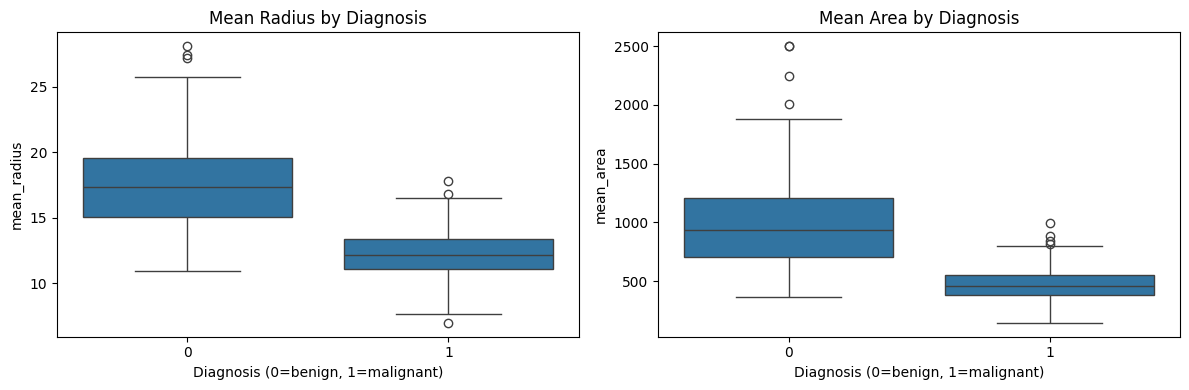

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x='diagnosis', y='mean_radius', data=df, ax=axes[0])
axes[0].set_title('Mean Radius by Diagnosis')
axes[0].set_xlabel('Diagnosis (0=benign, 1=malignant)')

sns.boxplot(x='diagnosis', y='mean_area', data=df, ax=axes[1])
axes[1].set_title('Mean Area by Diagnosis')
axes[1].set_xlabel('Diagnosis (0=benign, 1=malignant)')

plt.tight_layout()
plt.show()

## Visualisation: Histogram

The boxplot above gave me a summary view. Now I want to see the full distribution - how the values are spread out across all patients.

I use a histogram because it shows me the shape of each group, not just the median and quartiles. I can see where most values land and how much the two groups overlap.

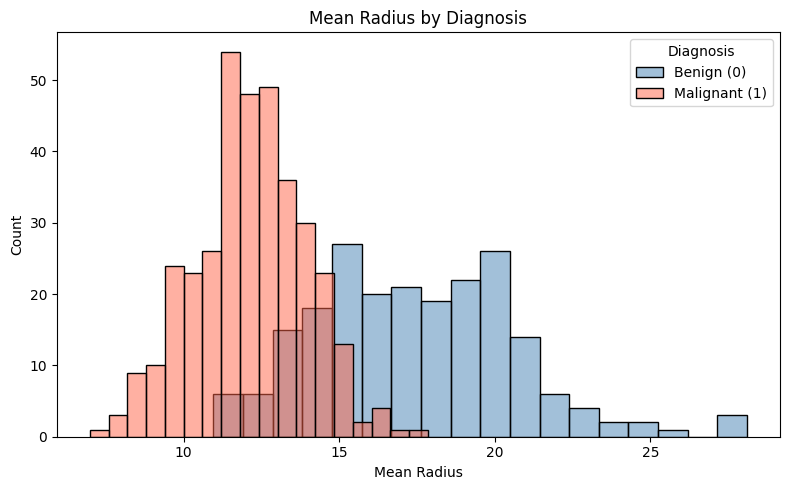

In [25]:
plot_df = df.copy()
plot_df['diagnosis_label'] = plot_df['diagnosis'].map({0: 'Benign (0)', 1: 'Malignant (1)'})

fig, ax = plt.subplots(figsize=(8, 5))

sns.histplot(
    data=plot_df[plot_df['diagnosis_label'] == 'Benign (0)'],
    x='mean_radius',
    bins=18,
    alpha=0.5,
    color='steelblue',
    label='Benign (0)',
    ax=ax
)

sns.histplot(
    data=plot_df[plot_df['diagnosis_label'] == 'Malignant (1)'],
    x='mean_radius',
    bins=18,
    alpha=0.5,
    color='tomato',
    label='Malignant (1)',
    ax=ax
)

ax.set_title('Mean Radius by Diagnosis')
ax.set_xlabel('Mean Radius')
ax.set_ylabel('Count')
ax.legend(title='Diagnosis')

plt.tight_layout()
plt.show()

The histogram shows both groups on the same chart. Malignant cases (red) are more to the left with smaller radius values. Benign cases (blue) are more to the right. There is some overlap in the middle, which means radius alone cannot perfectly separate the two groups, but it is still a useful feature.